# Fake News Detection
**Datasets:** LIAR (short political statements) + FakeNewsNet/BuzzFeed (full articles)  
**Models:** TF-IDF+LR baseline → BiLSTM+Metadata → DistilBERT → Ensemble  
**Goal:** Binary classification (Real vs Fake) with cross-domain evaluation

## Cell 1 — Install Dependencies

In [42]:
# Run once — restart runtime after this cell completes
!pip install -q transformers==4.41.2 datasets torch torchmetrics scikit-learn
!pip install -q nltk matplotlib seaborn tqdm

## Cell 2 — Mount Google Drive & Upload Data

In [43]:
from google.colab import files
import os, zipfile

uploaded = files.upload()

for fname in uploaded:
    with zipfile.ZipFile(fname) as z:
        z.extractall('/content/data/')

print("\nFiles in /content/data:")
for f in sorted(os.listdir('/content/data'))[:50]:
    print(f)

check_paths = [
    '/content/data/train.tsv',
    '/content/data/valid.tsv',
    '/content/data/test.tsv',
    '/content/data/BuzzFeed_fake_news_content.csv',
    '/content/data/BuzzFeed_real_news_content.csv',
    '/content/data/PolitiFact_fake_news_content.csv',
    '/content/data/PolitiFact_real_news_content.csv',
]

print("\nVerification:")
for p in check_paths:
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'[{status}] {p}')

Saving FakeNewsNet.zip to FakeNewsNet (1).zip
Saving LIAR.zip to LIAR (1).zip

Files in /content/data:
BuzzFeedNews.txt
BuzzFeedNewsUser.txt
BuzzFeedUser.txt
BuzzFeedUserFeature.mat
BuzzFeedUserUser.txt
BuzzFeed_fake_news_content.csv
BuzzFeed_real_news_content.csv
PolitiFactNews.txt
PolitiFactNewsUser.txt
PolitiFactUser.txt
PolitiFactUserFeature.mat
PolitiFactUserUser.txt
PolitiFact_fake_news_content.csv
PolitiFact_real_news_content.csv
README
test.tsv
train.tsv
valid.tsv

Verification:
[OK] /content/data/train.tsv
[OK] /content/data/valid.tsv
[OK] /content/data/test.tsv
[OK] /content/data/BuzzFeed_fake_news_content.csv
[OK] /content/data/BuzzFeed_real_news_content.csv
[OK] /content/data/PolitiFact_fake_news_content.csv
[OK] /content/data/PolitiFact_real_news_content.csv


## Cell 3 — Imports & Reproducibility

In [44]:
import os, csv, re, random, collections, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm.auto import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, roc_auc_score, confusion_matrix,
                              classification_report)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder

from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                           get_linear_schedule_with_warmup)

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

# Reproducibility
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
set_seed()

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Cell 4 — Load Datasets

In [45]:
# ── LIAR label binarization ──────────────────────────────────────────────────
# 6 original labels → binary
# Rationale: 'half-true' is ambiguous; we follow Wang (2017) convention:
#   FAKE = pants-fire, false, barely-true
#   REAL = true, mostly-true, half-true
FAKE_LABELS = {'pants-fire', 'false', 'barely-true'}
REAL_LABELS = {'true', 'mostly-true', 'half-true'}

def binarize(label):
    if label in FAKE_LABELS: return 1   # 1 = FAKE
    if label in REAL_LABELS: return 0   # 0 = REAL
    return None

# LIAR columns: id, label, statement, subject, speaker, job, state, party,
#               barely_true_ct, false_ct, half_true_ct, mostly_true_ct, pants_fire_ct, context
LIAR_COLS = ['id','label','statement','subject','speaker','job',
             'state','party','barely_true_ct','false_ct',
             'half_true_ct','mostly_true_ct','pants_fire_ct','context']

def load_liar(path):
    records = []
    with open(path, newline='', encoding='utf-8', errors='replace') as f:
        for row in csv.reader(f, delimiter='\t'):
            if len(row) < 14: continue
            d = dict(zip(LIAR_COLS, row))
            d['binary_label'] = binarize(d['label'])
            if d['binary_label'] is None: continue
            # credit history: 5 counts → normalize by total to get proportions
            try:
                counts = [int(d[c]) for c in
                          ['barely_true_ct','false_ct','half_true_ct',
                           'mostly_true_ct','pants_fire_ct']]
            except ValueError:
                counts = [0]*5
            total = sum(counts) + 1e-9
            d['credit_features'] = [c / total for c in counts]   # 5-dim normalized
            d['credit_total'] = sum(counts)                        # experience proxy
            records.append(d)
    return records

liar_train = load_liar('/content/data/train.tsv')
liar_val   = load_liar('/content/data/valid.tsv')
liar_test  = load_liar('/content/data/test.tsv')

print(f'LIAR  train={len(liar_train)}  val={len(liar_val)}  test={len(liar_test)}')

# ── FakeNewsNet / BuzzFeed ───────────────────────────────────────────────────
def load_buzzfeed(fake_path, real_path):
    records = []
    for path, lbl in [(fake_path, 1), (real_path, 0)]:
        with open(path, newline='', encoding='utf-8', errors='replace') as f:
            for row in csv.DictReader(f):
                text = (row.get('text') or '').strip()
                title = (row.get('title') or '').strip()
                if not text and not title: continue
                records.append({
                    'id': row.get('id',''),
                    'title': title,
                    'text': text,
                    'combined': (title + ' ' + text).strip(),
                    'binary_label': lbl
                })
    return records

buzzfeed_all = load_buzzfeed(
    '/content/data/BuzzFeed_fake_news_content.csv',
    '/content/data/BuzzFeed_real_news_content.csv'
)
print(f'BuzzFeed total={len(buzzfeed_all)}  fake={sum(r["binary_label"] for r in buzzfeed_all)}  real={sum(1-r["binary_label"] for r in buzzfeed_all)}')

# BuzzFeed split: 70/15/15 stratified
from sklearn.model_selection import train_test_split
bf_labels = [r['binary_label'] for r in buzzfeed_all]
bf_train_val, bf_test = train_test_split(buzzfeed_all, test_size=0.15, random_state=SEED, stratify=bf_labels)
bf_tv_labels = [r['binary_label'] for r in bf_train_val]
bf_train, bf_val = train_test_split(bf_train_val, test_size=0.176, random_state=SEED, stratify=bf_tv_labels)
print(f'BuzzFeed  train={len(bf_train)}  val={len(bf_val)}  test={len(bf_test)}')

LIAR  train=10238  val=1284  test=1267
BuzzFeed total=182  fake=91  real=91
BuzzFeed  train=126  val=28  test=28


## Cell 5 — Exploratory Data Analysis

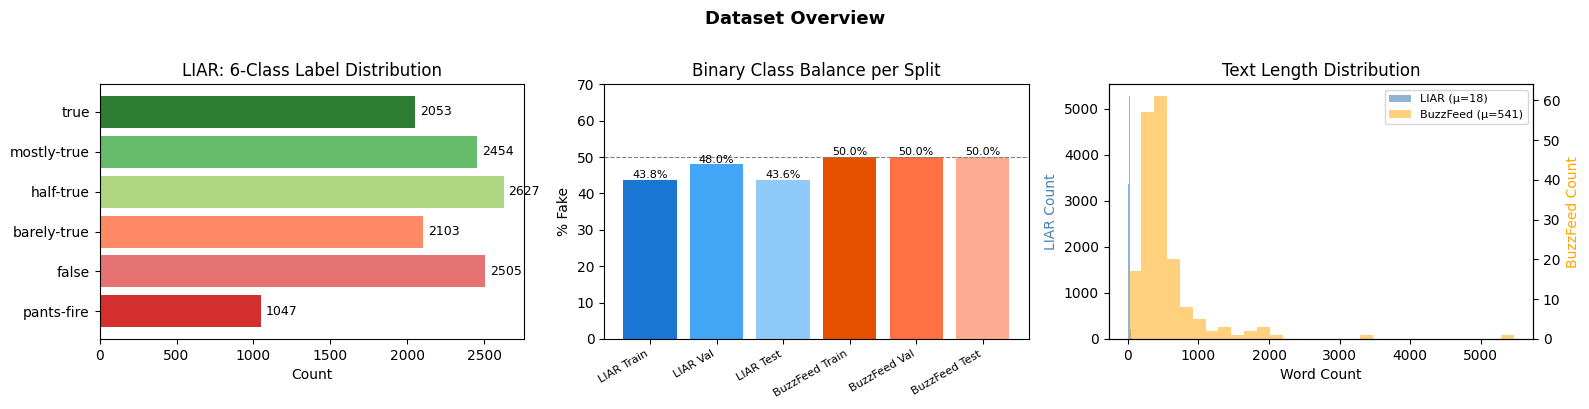


=== Dataset Summary ===
Split                     N   Fake   Real   Fake%
----------------------------------------------
LIAR Train            10238   4486   5752   43.8%
LIAR Val               1284    616    668   48.0%
LIAR Test              1267    553    714   43.6%
BuzzFeed Train          126     63     63   50.0%
BuzzFeed Val             28     14     14   50.0%
BuzzFeed Test            28     14     14   50.0%


In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. LIAR original 6-class distribution
liar_all = liar_train + liar_val + liar_test
orig_labels = [r['label'] for r in liar_all]
label_order = ['pants-fire','false','barely-true','half-true','mostly-true','true']
counts = [orig_labels.count(l) for l in label_order]
colors = ['#d32f2f','#e57373','#ff8a65','#aed581','#66bb6a','#2e7d32']
axes[0].barh(label_order, counts, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('LIAR: 6-Class Label Distribution')
for i, v in enumerate(counts):
    axes[0].text(v+30, i, str(v), va='center', fontsize=9)

# 2. Binary label distribution across splits
splits_data = {
    'LIAR Train': liar_train, 'LIAR Val': liar_val, 'LIAR Test': liar_test,
    'BuzzFeed Train': bf_train, 'BuzzFeed Val': bf_val, 'BuzzFeed Test': bf_test
}
split_names, fake_pcts = [], []
for name, data in splits_data.items():
    lbls = [r['binary_label'] for r in data]
    split_names.append(name)
    fake_pcts.append(100 * sum(lbls) / len(lbls))
bars = axes[1].bar(range(len(split_names)), fake_pcts, color=['#1976d2','#42a5f5','#90caf9','#e65100','#ff7043','#ffab91'])
axes[1].axhline(50, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xticks(range(len(split_names)))
axes[1].set_xticklabels(split_names, rotation=30, ha='right', fontsize=8)
axes[1].set_ylabel('% Fake')
axes[1].set_title('Binary Class Balance per Split')
axes[1].set_ylim(0, 70)
for bar, pct in zip(bars, fake_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2, pct+0.5, f'{pct:.1f}%', ha='center', fontsize=8)

# 3. Statement/article word length distributions
liar_lens = [len(r['statement'].split()) for r in liar_train]
bf_lens = [len(r['combined'].split()) for r in buzzfeed_all]
axes[2].hist(liar_lens, bins=40, alpha=0.6, label=f'LIAR (μ={np.mean(liar_lens):.0f})', color='steelblue')
ax2 = axes[2].twinx()
ax2.hist(bf_lens, bins=30, alpha=0.5, label=f'BuzzFeed (μ={np.mean(bf_lens):.0f})', color='orange')
axes[2].set_xlabel('Word Count')
axes[2].set_ylabel('LIAR Count', color='steelblue')
ax2.set_ylabel('BuzzFeed Count', color='orange')
axes[2].set_title('Text Length Distribution')
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
axes[2].legend(lines1+lines2, labels1+labels2, fontsize=8)

plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats table
print('\n=== Dataset Summary ===')
print(f'{"Split":<20} {"N":>6} {"Fake":>6} {"Real":>6} {"Fake%":>7}')
print('-'*46)
for name, data in splits_data.items():
    lbls = [r['binary_label'] for r in data]
    n, nf, nr = len(lbls), sum(lbls), len(lbls)-sum(lbls)
    print(f'{name:<20} {n:>6} {nf:>6} {nr:>6} {100*nf/n:>6.1f}%')

## Cell 6 — Text Preprocessing

In [47]:
def clean_text(text, remove_stops=False):
    """Lowercase, remove URLs/HTML/special chars, collapse whitespace."""
    if not text: return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)     # URLs
    text = re.sub(r'<[^>]+>', ' ', text)               # HTML tags
    text = re.sub(r'[^a-z0-9\s\']', ' ', text)        # special chars (keep apostrophes)
    text = re.sub(r'\s+', ' ', text).strip()
    if remove_stops:
        tokens = text.split()
        text = ' '.join(t for t in tokens if t not in STOPWORDS)
    return text

# Apply to LIAR
for split in [liar_train, liar_val, liar_test]:
    for r in split:
        r['clean_statement'] = clean_text(r['statement'])

# Apply to BuzzFeed
for split in [bf_train, bf_val, bf_test]:
    for r in split:
        r['clean_text'] = clean_text(r['combined'])

# Spot-check
print('LIAR original:', liar_train[0]['statement'])
print('LIAR cleaned: ', liar_train[0]['clean_statement'])
print()
print('BuzzFeed original (first 100):', buzzfeed_all[0]['combined'][:100])
print('BuzzFeed cleaned  (first 100):', bf_train[0]['clean_text'][:100])

# Leakage check: ensure no LIAR test IDs appear in train
train_ids = {r['id'] for r in liar_train}
test_ids  = {r['id'] for r in liar_test}
val_ids   = {r['id'] for r in liar_val}
print(f'\nLIAR leakage check — train∩test: {len(train_ids & test_ids)}, train∩val: {len(train_ids & val_ids)}')
bf_train_ids = {r['id'] for r in bf_train}
bf_test_ids  = {r['id'] for r in bf_test}
print(f'BuzzFeed leakage check — train∩test: {len(bf_train_ids & bf_test_ids)}')

LIAR original: Says the Annies List political group supports third-trimester abortions on demand.
LIAR cleaned:  says the annies list political group supports third trimester abortions on demand

BuzzFeed original (first 100): Proof The Mainstream Media Is Manipulating The Election By Taking Bill Clinton Out Of Context I woke
BuzzFeed cleaned  (first 100): magistrate won't order federal arraignment for bombing suspect under the radar blog archives select 

LIAR leakage check — train∩test: 0, train∩val: 0
BuzzFeed leakage check — train∩test: 0


## Cell 7 — Vocabulary & GloVe Embeddings (for BiLSTM)

In [48]:
# Download GloVe 6B 100d
import os
if not os.path.exists('/content/glove.6B.100d.txt'):
    print('Downloading GloVe...')
    !wget -q https://nlp.stanford.edu/data/glove.6B.zip -O /content/glove.6B.zip
    !unzip -q /content/glove.6B.zip -d /content/
    print('Done.')
else:
    print('GloVe already present.')

# Build vocabulary from LIAR train only (no leakage)
MAX_VOCAB = 30000
EMBED_DIM = 100
PAD_IDX = 0
UNK_IDX = 1

token_counts = collections.Counter()
for r in liar_train:
    token_counts.update(r['clean_statement'].split())

vocab = ['<PAD>', '<UNK>'] + [w for w, _ in token_counts.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocabulary size: {len(vocab)}')

# Load GloVe vectors for vocab words
glove = {}
with open('/content/glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

embed_matrix = np.zeros((len(vocab), EMBED_DIM), dtype=np.float32)
hit, miss = 0, 0
for word, idx in word2idx.items():
    if word in glove:
        embed_matrix[idx] = glove[word]
        hit += 1
    else:
        embed_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM)  # random init for OOV
        miss += 1

print(f'GloVe coverage: {hit}/{len(vocab)} ({100*hit/len(vocab):.1f}%)')
embed_matrix = torch.tensor(embed_matrix)

GloVe already present.
Vocabulary size: 12400
GloVe coverage: 11625/12400 (93.8%)


## Cell 8 — Baseline: TF-IDF + Logistic Regression

In [49]:
def compute_metrics(y_true, y_pred, y_prob=None, name=''):
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f'{name:<30} Acc={acc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Rec={rec:.4f}  AUC={auc:.4f}')
    return {'name': name, 'acc': acc, 'f1': f1, 'prec': prec, 'rec': rec, 'auc': auc}

# ── TF-IDF on LIAR ──────────────────────────────────────────────────────────
X_train_text = [r['clean_statement'] for r in liar_train]
X_val_text   = [r['clean_statement'] for r in liar_val]
X_test_text  = [r['clean_statement'] for r in liar_test]
y_train = [r['binary_label'] for r in liar_train]
y_val   = [r['binary_label'] for r in liar_val]
y_test  = [r['binary_label'] for r in liar_test]

# Class weights for imbalance
cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
cw_dict = {0: cw[0], 1: cw[1]}
print(f'Class weights: Real={cw_dict[0]:.3f}, Fake={cw_dict[1]:.3f}')

tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)
X_tr_tfidf = tfidf.fit_transform(X_train_text)
X_va_tfidf = tfidf.transform(X_val_text)
X_te_tfidf = tfidf.transform(X_test_text)

lr_liar = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=SEED)
lr_liar.fit(X_tr_tfidf, y_train)

results = []
for name, X, y in [('TF-IDF+LR [LIAR val]', X_va_tfidf, y_val),
                   ('TF-IDF+LR [LIAR test]', X_te_tfidf, y_test)]:
    pred = lr_liar.predict(X)
    prob = lr_liar.predict_proba(X)[:, 1]
    results.append(compute_metrics(y, pred, prob, name))

print()

# ── TF-IDF on BuzzFeed ──────────────────────────────────────────────────────
X_bf_tr = [r['clean_text'] for r in bf_train]
X_bf_va = [r['clean_text'] for r in bf_val]
X_bf_te = [r['clean_text'] for r in bf_test]
y_bf_tr = [r['binary_label'] for r in bf_train]
y_bf_va = [r['binary_label'] for r in bf_val]
y_bf_te = [r['binary_label'] for r in bf_test]

tfidf_bf = TfidfVectorizer(ngram_range=(1,2), max_features=50000, sublinear_tf=True)
X_bf_tr_tf = tfidf_bf.fit_transform(X_bf_tr)
X_bf_va_tf = tfidf_bf.transform(X_bf_va)
X_bf_te_tf = tfidf_bf.transform(X_bf_te)

lr_bf = LogisticRegression(max_iter=1000, class_weight='balanced', C=1.0, random_state=SEED)
lr_bf.fit(X_bf_tr_tf, y_bf_tr)
for name, X, y in [('TF-IDF+LR [BuzzFeed val]', X_bf_va_tf, y_bf_va),
                   ('TF-IDF+LR [BuzzFeed test]', X_bf_te_tf, y_bf_te)]:
    pred = lr_bf.predict(X)
    prob = lr_bf.predict_proba(X)[:, 1]
    results.append(compute_metrics(y, pred, prob, name))

Class weights: Real=0.890, Fake=1.141
TF-IDF+LR [LIAR val]           Acc=0.6246  F1=0.6237  Prec=0.6238  Rec=0.6236  AUC=0.6797
TF-IDF+LR [LIAR test]          Acc=0.6385  F1=0.6333  Prec=0.6331  Rec=0.6336  AUC=0.6754

TF-IDF+LR [BuzzFeed val]       Acc=0.8214  F1=0.8155  Prec=0.8684  Rec=0.8214  AUC=0.9286
TF-IDF+LR [BuzzFeed test]      Acc=0.6786  F1=0.6782  Prec=0.6795  Rec=0.6786  AUC=0.7092


## Cell 8b — Metadata-Only Baseline (Speaker Credit History)

In [ ]:
# ── Metadata-Only Baseline ──────────────────────────────────────────────────
# Diagnostic: can speaker credit history alone classify fake news?
# Uses ONLY the 6-dim metadata vector (5 credit proportions + log(total+1))
# No text features. Establishes the metadata signal strength in isolation.

import numpy as np
from sklearn.linear_model import LogisticRegression as SklearnLR

def build_meta_matrix(records):
    rows = []
    for r in records:
        props = r['credit_features']          # 5-dim normalized (from Cell 4)
        log_total = np.log(r['credit_total'] + 1)
        rows.append(np.array(props + [log_total], dtype=float))
    return np.array(rows)

X_train_meta = build_meta_matrix(liar_train)
X_val_meta   = build_meta_matrix(liar_val)
X_test_meta  = build_meta_matrix(liar_test)

y_train_bin = np.array([r['binary_label'] for r in liar_train])
y_val_bin   = np.array([r['binary_label'] for r in liar_val])
y_test_bin  = np.array([r['binary_label'] for r in liar_test])

print("Sample meta vectors (first 3 rows):")
print(X_train_meta[:3])
print("Label distribution in train:", collections.Counter(y_train_bin))

meta_lr = SklearnLR(class_weight='balanced', max_iter=1000, random_state=42)
meta_lr.fit(X_train_meta, y_train_bin)

for split_name, X, y in [('val', X_val_meta, y_val_bin), ('test', X_test_meta, y_test_bin)]:
    preds = meta_lr.predict(X)
    probs_all = meta_lr.predict_proba(X)
    fake_col = list(meta_lr.classes_).index(1)
    probs = probs_all[:, fake_col]
    m = compute_metrics(y, preds, probs, f'Metadata-Only LR [LIAR {split_name}]')
    if split_name == 'test':
        results.append(m)


## Cell 9 — BiLSTM + Speaker Metadata Model

In [50]:
# ── Dataset helper ───────────────────────────────────────────────────────────
MAX_SEQ_LEN = 64   # LIAR statements are short (~18 words avg)
PARTY_VOCAB = ['republican','democrat','none','independent','organization','libertarian','green','other']
party2idx = {p: i for i, p in enumerate(PARTY_VOCAB)}

def encode_tokens(text, max_len=MAX_SEQ_LEN):
    tokens = text.split()[:max_len]
    ids = [word2idx.get(t, UNK_IDX) for t in tokens]
    pad_len = max_len - len(ids)
    ids = ids + [PAD_IDX] * pad_len
    return ids

class LIARDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, i):
        r = self.records[i]
        token_ids = torch.tensor(encode_tokens(r['clean_statement']), dtype=torch.long)
        # Credit history features (5-dim normalized proportions + log(total+1))
        meta = torch.tensor(
            r['credit_features'] + [np.log1p(r['credit_total'])],
            dtype=torch.float32
        )
        label = torch.tensor(r['binary_label'], dtype=torch.long)
        return token_ids, meta, label

BATCH_SIZE = 64
train_ds = LIARDataset(liar_train)
val_ds   = LIARDataset(liar_val)
test_ds  = LIARDataset(liar_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)
print('DataLoaders ready.')

DataLoaders ready.


In [51]:
class BiLSTMClassifier(nn.Module):
    """
    BiLSTM over GloVe embeddings fused with speaker credit-history metadata.
    Architecture:
      Embedding (pretrained GloVe, fine-tunable) → BiLSTM → attention pooling
      → concat with 6-dim metadata → MLP → sigmoid
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, meta_dim,
                 num_layers=2, dropout=0.4, pretrained_embed=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        if pretrained_embed is not None:
            self.embedding.weight.data.copy_(pretrained_embed)

        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        # Attention over LSTM outputs
        self.attn = nn.Linear(hidden_dim * 2, 1)

        self.dropout = nn.Dropout(dropout)
        fuse_dim = hidden_dim * 2 + meta_dim
        self.classifier = nn.Sequential(
            nn.Linear(fuse_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 2)
        )

    def forward(self, token_ids, meta):
        emb = self.dropout(self.embedding(token_ids))      # (B, L, E)
        out, _ = self.lstm(emb)                             # (B, L, 2H)
        # Attention pooling: weighted sum over time steps
        attn_w = torch.softmax(self.attn(out), dim=1)      # (B, L, 1)
        ctx = (out * attn_w).sum(dim=1)                    # (B, 2H)
        # Fuse with metadata
        fused = torch.cat([ctx, meta], dim=1)              # (B, 2H + meta_dim)
        return self.classifier(fused)                      # (B, 2)


def train_epoch(model, loader, optimizer, criterion, scheduler=None):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for token_ids, meta, labels in loader:
        token_ids, meta, labels = token_ids.to(DEVICE), meta.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        logits = model(token_ids, meta)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler: scheduler.step()
        total_loss += loss.item() * labels.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), f1_score(labels_all, preds_all, average='macro')


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    preds_all, labels_all, probs_all = [], [], []
    for token_ids, meta, labels in loader:
        token_ids, meta = token_ids.to(DEVICE), meta.to(DEVICE)
        logits = model(token_ids, meta)
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())
        probs_all.extend(probs.cpu().numpy())
    return np.array(labels_all), np.array(preds_all), np.array(probs_all)

In [52]:
# ── Ablation A: BiLSTM WITHOUT metadata (text-only) ─────────────────────────
# We zero-out meta at runtime by passing zeros — keeps architecture identical
# so comparison is fair.

META_DIM = 6  # 5 credit proportions + log(total)
HIDDEN_DIM = 256
EPOCHS_LSTM = 10

cw_tensor = torch.tensor([cw[0], cw[1]], dtype=torch.float32).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)

bilstm_results = {}

for ablation_name, use_meta in [('BiLSTM (no metadata)', False), ('BiLSTM + Metadata', True)]:
    set_seed()
    model = BiLSTMClassifier(
        vocab_size=len(vocab), embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
        meta_dim=META_DIM, num_layers=2, dropout=0.4,
        pretrained_embed=embed_matrix
    ).to(DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    total_steps = len(train_loader) * EPOCHS_LSTM
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps
    )

    best_val_f1, best_state, history = 0.0, None, []
    print(f'\nTraining {ablation_name}')

    for epoch in range(1, EPOCHS_LSTM+1):
        if not use_meta:
            # Monkey-patch loader to zero meta
            def _eval_no_meta(loader):
                model.eval()
                preds_all, labels_all, probs_all = [], [], []
                with torch.no_grad():
                    for token_ids, meta, labels in loader:
                        token_ids = token_ids.to(DEVICE)
                        meta = torch.zeros_like(meta).to(DEVICE)
                        logits = model(token_ids, meta)
                        probs = torch.softmax(logits, dim=1)[:, 1]
                        preds_all.extend(logits.argmax(1).cpu().numpy())
                        labels_all.extend(labels.numpy())
                        probs_all.extend(probs.cpu().numpy())
                return np.array(labels_all), np.array(preds_all), np.array(probs_all)

            # Train with zeroed meta
            model.train()
            total_loss, ep_preds, ep_labels = 0.0, [], []
            for token_ids, meta, labels in train_loader:
                token_ids, labels = token_ids.to(DEVICE), labels.to(DEVICE)
                meta = torch.zeros_like(meta).to(DEVICE)
                optimizer.zero_grad()
                logits = model(token_ids, meta)
                loss = criterion(logits, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
                total_loss += loss.item() * labels.size(0)
                ep_preds.extend(logits.argmax(1).cpu().numpy())
                ep_labels.extend(labels.cpu().numpy())
            tr_loss = total_loss / len(train_loader.dataset)
            tr_f1 = f1_score(ep_labels, ep_preds, average='macro')
            val_y, val_p, val_prob = _eval_no_meta(val_loader)
        else:
            tr_loss, tr_f1 = train_epoch(model, train_loader, optimizer, criterion, scheduler)
            val_y, val_p, val_prob = evaluate(model, val_loader)

        val_f1 = f1_score(val_y, val_p, average='macro')
        val_acc = accuracy_score(val_y, val_p)
        history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_f1': tr_f1,
                        'val_f1': val_f1, 'val_acc': val_acc})

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 2 == 0 or epoch == EPOCHS_LSTM:
            print(f'  Epoch {epoch:2d} | tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} | val_f1={val_f1:.4f} val_acc={val_acc:.4f}')

    # Load best checkpoint and evaluate on test
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})
    if use_meta:
        te_y, te_p, te_prob = evaluate(model, test_loader)
    else:
        te_y, te_p, te_prob = _eval_no_meta(test_loader)

    m = compute_metrics(te_y, te_p, te_prob, f'{ablation_name} [LIAR test]')
    results.append(m)
    bilstm_results[ablation_name] = {'model': model, 'history': history,
                                      'best_state': best_state, 'use_meta': use_meta}


Training BiLSTM (no metadata)
  Epoch  2 | tr_loss=0.6731 tr_f1=0.5877 | val_f1=0.5791 val_acc=0.5919
  Epoch  4 | tr_loss=0.6357 tr_f1=0.6462 | val_f1=0.6402 val_acc=0.6402
  Epoch  6 | tr_loss=0.5540 tr_f1=0.7215 | val_f1=0.6264 val_acc=0.6269
  Epoch  8 | tr_loss=0.4641 tr_f1=0.7838 | val_f1=0.6184 val_acc=0.6192
  Epoch 10 | tr_loss=0.4183 tr_f1=0.8084 | val_f1=0.6109 val_acc=0.6121
BiLSTM (no metadata) [LIAR test] Acc=0.6133  F1=0.6107  Prec=0.6111  Rec=0.6128  AUC=0.6608

Training BiLSTM + Metadata
  Epoch  2 | tr_loss=0.5312 tr_f1=0.7206 | val_f1=0.7394 val_acc=0.7399
  Epoch  4 | tr_loss=0.4881 tr_f1=0.7493 | val_f1=0.7512 val_acc=0.7516
  Epoch  6 | tr_loss=0.4220 tr_f1=0.7980 | val_f1=0.7483 val_acc=0.7500
  Epoch  8 | tr_loss=0.3448 tr_f1=0.8458 | val_f1=0.7302 val_acc=0.7305
  Epoch 10 | tr_loss=0.3033 tr_f1=0.8646 | val_f1=0.7240 val_acc=0.7243
BiLSTM + Metadata [LIAR test]  Acc=0.7498  F1=0.7462  Prec=0.7458  Rec=0.7468  AUC=0.8339


## Cell 10 — DistilBERT Fine-Tuning on LIAR

In [53]:
MODEL_NAME   = 'distilbert-base-uncased'
BERT_MAX_LEN = 64
BERT_BATCH   = 32
BERT_EPOCHS  = 6
BERT_LR      = 2e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def make_liar_input(records):
    # Raw statement only — metadata will be injected as numeric features, not text
    return [r['clean_statement'] for r in records]

liar_train_texts = make_liar_input(liar_train)
liar_val_texts   = make_liar_input(liar_val)
liar_test_texts  = make_liar_input(liar_test)

# Party one-hot (6 categories)
PARTY_LIST = ['republican','democrat','none','independent','organization','other']
def party_onehot(party):
    p = party.strip().lower()
    idx = PARTY_LIST.index(p) if p in PARTY_LIST else len(PARTY_LIST)-1
    oh = [0.0]*len(PARTY_LIST)
    oh[idx] = 1.0
    return oh

def build_meta_vector(r):
    # 5 normalized credit history proportions
    credits = r['credit_features']          # already normalized in Cell 4
    log_total = [np.log1p(r['credit_total'])]
    party = party_onehot(r['party'])
    # 5 + 1 + 6 = 12-dim metadata vector
    return credits + log_total + party

META_DIM_BERT = 12

class LIARBertDataset(Dataset):
    def __init__(self, texts, records, max_len):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.meta   = torch.tensor([build_meta_vector(r) for r in records], dtype=torch.float32)
        self.labels = torch.tensor([r['binary_label'] for r in records], dtype=torch.long)

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, i):
        return {
            'input_ids':      self.encodings['input_ids'][i],
            'attention_mask': self.encodings['attention_mask'][i],
            'meta':           self.meta[i],
            'labels':         self.labels[i]
        }

bert_train_ds = LIARBertDataset(liar_train_texts, liar_train, BERT_MAX_LEN)
bert_val_ds   = LIARBertDataset(liar_val_texts,   liar_val,   BERT_MAX_LEN)
bert_test_ds  = LIARBertDataset(liar_test_texts,  liar_test,  BERT_MAX_LEN)

bert_train_loader = DataLoader(bert_train_ds, batch_size=BERT_BATCH, shuffle=True)
bert_val_loader   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH)
bert_test_loader  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH)
print(f'BERT DataLoaders ready. Meta vector dim: {META_DIM_BERT}')
print(f'Sample meta vector: {build_meta_vector(liar_train[0])}')

BERT DataLoaders ready. Meta vector dim: 12
Sample meta vector: [0.0, 0.9999999989999999, 0.0, 0.0, 0.0, np.float64(0.6931471805599453), 1.0, 0.0, 0.0, 0.0, 0.0, 0.0]


In [54]:
from transformers import DistilBertModel, DistilBertConfig

class DistilBertWithMeta(nn.Module):
    """
    DistilBERT encoder whose CLS representation is late-fused with structured
    metadata (credit history + party) before classification.

    Architecture:
        DistilBERT → CLS pooling (768-d)
            ↘
              concat → LayerNorm → Dropout → Linear(256) → GELU
                                                              → Linear(2)
            ↗
        Meta MLP: 12-d → Linear(64) → GELU → Linear(64)

    Rationale: the metadata (speaker credit history) is the dominant predictive
    signal on LIAR (mean fake-history proportion 0.69 for fake vs 0.37 for real).
    Injecting it after the transformer keeps the two modalities independent during
    encoding and lets the fusion layer learn their relative importance.
    """
    def __init__(self, bert_name, meta_dim, dropout=0.2):
        super().__init__()
        cfg = DistilBertConfig.from_pretrained(bert_name, dropout=dropout,
                                               attention_dropout=dropout)
        self.bert = DistilBertModel.from_pretrained(bert_name, config=cfg)

        hidden = self.bert.config.dim  # 768

        # Small MLP to project metadata into the same space as BERT CLS
        self.meta_proj = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
        )

        fuse_dim = hidden + 64
        self.classifier = nn.Sequential(
            nn.LayerNorm(fuse_dim),
            nn.Dropout(0.3),
            nn.Linear(fuse_dim, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(256, 2)
        )

    def forward(self, input_ids, attention_mask, meta):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]     # (B, 768)
        m   = self.meta_proj(meta)               # (B, 64)
        fused = torch.cat([cls, m], dim=1)       # (B, 832)
        return self.classifier(fused)            # (B, 2)


set_seed()
bert_model = DistilBertWithMeta(MODEL_NAME, meta_dim=META_DIM_BERT, dropout=0.2).to(DEVICE)

# Different LRs for pretrained backbone vs fresh fusion layers
bert_backbone_params = list(bert_model.bert.parameters())
bert_head_params     = list(bert_model.meta_proj.parameters()) + \
                       list(bert_model.classifier.parameters())

bert_optimizer = torch.optim.AdamW([
    {'params': bert_backbone_params, 'lr': BERT_LR,      'weight_decay': 0.01},
    {'params': bert_head_params,     'lr': BERT_LR * 10, 'weight_decay': 0.01},
])

total_steps_bert = len(bert_train_loader) * BERT_EPOCHS
bert_scheduler = get_linear_schedule_with_warmup(
    bert_optimizer,
    num_warmup_steps=int(0.1 * total_steps_bert),
    num_training_steps=total_steps_bert
)

bert_criterion = nn.CrossEntropyLoss(weight=cw_tensor)

def bert_train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for batch in tqdm(loader, leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        meta           = batch['meta'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, meta)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * labels.size(0)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), f1_score(labels_all, preds_all, average='macro')

@torch.no_grad()
def bert_evaluate(model, loader):
    model.eval()
    preds_all, labels_all, probs_all = [], [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        meta           = batch['meta'].to(DEVICE)
        labels         = batch['labels']
        logits = model(input_ids, attention_mask, meta)
        probs  = torch.softmax(logits, dim=1)[:, 1]
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())
        probs_all.extend(probs.cpu().numpy())
    return np.array(labels_all), np.array(preds_all), np.array(probs_all)

best_bert_f1, best_bert_state, bert_history = 0.0, None, []
PATIENCE, no_improve = 3, 0
print('Training DistilBERT+Meta (CLS ⊕ credit-history fusion)...')
print(f'Backbone LR={BERT_LR:.0e} | Head LR={BERT_LR*10:.0e} | Epochs={BERT_EPOCHS}')

for epoch in range(1, BERT_EPOCHS + 1):
    tr_loss, tr_f1 = bert_train_epoch(bert_model, bert_train_loader,
                                       bert_optimizer, bert_criterion, bert_scheduler)
    val_y, val_p, val_prob = bert_evaluate(bert_model, bert_val_loader)
    val_f1  = f1_score(val_y, val_p, average='macro')
    val_acc = accuracy_score(val_y, val_p)
    bert_history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_f1': tr_f1,
                         'val_f1': val_f1, 'val_acc': val_acc})

    improved = val_f1 > best_bert_f1
    if improved:
        best_bert_f1 = val_f1
        best_bert_state = {k: v.cpu().clone() for k, v in bert_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    marker = ' ✓' if improved else ''
    print(f'Epoch {epoch}/{BERT_EPOCHS} | tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} '
          f'| val_f1={val_f1:.4f} val_acc={val_acc:.4f}{marker}')

    if no_improve >= PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest val F1: {best_bert_f1:.4f}')
bert_model.load_state_dict({k: v.to(DEVICE) for k, v in best_bert_state.items()})
te_y, te_p, te_prob = bert_evaluate(bert_model, bert_test_loader)
m = compute_metrics(te_y, te_p, te_prob, 'DistilBERT+Meta [LIAR test]')
results.append(m)

Training DistilBERT+Meta (CLS ⊕ credit-history fusion)...
Backbone LR=2e-05 | Head LR=2e-04 | Epochs=6


  0%|          | 0/320 [00:00<?, ?it/s]

Epoch 1/6 | tr_loss=0.6501 tr_f1=0.6028 | val_f1=0.7272 val_acc=0.7305 ✓


  0%|          | 0/320 [00:00<?, ?it/s]

Epoch 2/6 | tr_loss=0.5171 tr_f1=0.7363 | val_f1=0.7256 val_acc=0.7321


...

Epoch 4/6 | tr_loss=0.4175 tr_f1=0.7992 | val_f1=0.7320 val_acc=0.7344


  0%|          | 0/320 [00:00<?, ?it/s]

Epoch 5/6 | tr_loss=0.3697 tr_f1=0.8288 | val_f1=0.7242 val_acc=0.7282


  0%|          | 0/320 [00:00<?, ?it/s]

Epoch 6/6 | tr_loss=0.3250 tr_f1=0.8524 | val_f1=0.7175 val_acc=0.7212
Early stopping at epoch 6

Best val F1: 0.7476
DistilBERT+Meta [LIAR test]    Acc=0.7403  F1=0.7394  Prec=0.7408  Rec=0.7447  AUC=0.8316


## Cell 11 — DistilBERT Fine-Tuning on BuzzFeed

In [ ]:
from torch.utils.data import Dataset as TorchDataset

class TextDataset(TorchDataset):
    """Text-only dataset for BuzzFeed DistilBERT (no metadata)."""
    def __init__(self, texts, labels, max_len):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {
            'input_ids':      self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels':         self.labels[idx],
        }

# BuzzFeed: full articles, no speaker metadata available → text-only DistilBERT
# Small dataset (182 articles) — lower LR, more epochs, early stopping
BERT_BF_MAX_LEN = 512
BERT_BF_BATCH   = 8
BERT_BF_EPOCHS  = 10
BERT_BF_LR      = 2e-5

def make_bf_texts(records):
    return [' '.join(r['clean_text'].split()[:400]) for r in records]

bf_train_ds_bert = TextDataset(make_bf_texts(bf_train), y_bf_tr, BERT_BF_MAX_LEN)
bf_val_ds_bert   = TextDataset(make_bf_texts(bf_val),   y_bf_va, BERT_BF_MAX_LEN)
bf_test_ds_bert  = TextDataset(make_bf_texts(bf_test),  y_bf_te, BERT_BF_MAX_LEN)

bf_train_loader_bert = DataLoader(bf_train_ds_bert, batch_size=BERT_BF_BATCH, shuffle=True)
bf_val_loader_bert   = DataLoader(bf_val_ds_bert,   batch_size=BERT_BF_BATCH)
bf_test_loader_bert  = DataLoader(bf_test_ds_bert,  batch_size=BERT_BF_BATCH)

# Separate train/eval functions for text-only DistilBERT (no 'meta' key)
def bf_train_epoch(model, loader, optimizer, criterion, scheduler):
    model.train()
    total_loss, preds_all, labels_all = 0.0, [], []
    for batch in tqdm(loader, leave=False):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels'].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item() * labels.size(0)
        preds_all.extend(outputs.logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.cpu().numpy())
    return total_loss / len(loader.dataset), f1_score(labels_all, preds_all, average='macro')

@torch.no_grad()
def bf_evaluate(model, loader):
    model.eval()
    preds_all, labels_all, probs_all = [], [], []
    for batch in loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['labels']
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1]
        preds_all.extend(outputs.logits.argmax(1).cpu().numpy())
        labels_all.extend(labels.numpy())
        probs_all.extend(probs.cpu().numpy())
    return np.array(labels_all), np.array(preds_all), np.array(probs_all)

set_seed()
bert_bf_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
).to(DEVICE)

cw_bf = compute_class_weight('balanced', classes=np.array([0,1]), y=y_bf_tr)
cw_bf_tensor = torch.tensor(cw_bf, dtype=torch.float32).to(DEVICE)

no_decay = ['bias', 'LayerNorm.weight']
bf_opt_params = [
    {'params': [p for n, p in bert_bf_model.named_parameters()
                if not any(nd in n for nd in no_decay)], 'weight_decay': 0.01},
    {'params': [p for n, p in bert_bf_model.named_parameters()
                if any(nd in n for nd in no_decay)], 'weight_decay': 0.0},
]
bf_optimizer  = torch.optim.AdamW(bf_opt_params, lr=BERT_BF_LR)
total_bf      = len(bf_train_loader_bert) * BERT_BF_EPOCHS
bf_scheduler  = get_linear_schedule_with_warmup(bf_optimizer, int(0.1 * total_bf), total_bf)
bf_criterion  = nn.CrossEntropyLoss(weight=cw_bf_tensor)

best_bf_f1, best_bf_state, bf_no_improve = 0.0, None, 0
BF_PATIENCE = 3
print('Training DistilBERT on BuzzFeed (text-only, full articles)...')

for epoch in range(1, BERT_BF_EPOCHS + 1):
    tr_loss, tr_f1 = bf_train_epoch(bert_bf_model, bf_train_loader_bert,
                                     bf_optimizer, bf_criterion, bf_scheduler)
    val_y, val_p, val_prob = bf_evaluate(bert_bf_model, bf_val_loader_bert)
    val_f1 = f1_score(val_y, val_p, average='macro')

    improved = val_f1 > best_bf_f1
    if improved:
        best_bf_f1 = val_f1
        best_bf_state = {k: v.cpu().clone() for k, v in bert_bf_model.state_dict().items()}
        bf_no_improve = 0
    else:
        bf_no_improve += 1

    marker = ' ✓' if improved else ''
    print(f'Epoch {epoch}/{BERT_BF_EPOCHS} | tr_loss={tr_loss:.4f} tr_f1={tr_f1:.4f} '
          f'| val_f1={val_f1:.4f}{marker}')

    if bf_no_improve >= BF_PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

print(f'\nBest val F1: {best_bf_f1:.4f}')
bert_bf_model.load_state_dict({k: v.to(DEVICE) for k, v in best_bf_state.items()})
te_y, te_p, te_prob = bf_evaluate(bert_bf_model, bf_test_loader_bert)
m = compute_metrics(te_y, te_p, te_prob, 'DistilBERT [BuzzFeed test]')
results.append(m)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training DistilBERT on BuzzFeed (text-only, full articles)...


  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1/10 | tr_loss=0.6869 tr_f1=0.5733 | val_f1=0.5333 ✓


  0%|          | 0/16 [00:00<?, ?it/s]

...

Epoch 8/10 | tr_loss=0.0186 tr_f1=1.0000 | val_f1=0.8916


  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 9/10 | tr_loss=0.0153 tr_f1=1.0000 | val_f1=0.8916


  0%|          | 0/16 [00:00<?, ?it/s]

Epoch 10/10 | tr_loss=0.0128 tr_f1=1.0000 | val_f1=0.8916
Early stopping at epoch 10

Best val F1: 0.8916
DistilBERT [BuzzFeed test]     Acc=0.6786  F1=0.6748  Prec=0.6872  Rec=0.6786  AUC=0.6990


## Cell 12 — Late-Fusion Ensemble (LIAR)

In [56]:
# Ensemble: weighted average of DistilBERT+Meta + BiLSTM+Metadata probabilities on LIAR test
# Alpha (BERT weight) searched on validation set — no test-set leakage

# Val probs from DistilBERT+Meta (uses bert_evaluate which expects 'meta' key)
bert_model.load_state_dict({k: v.to(DEVICE) for k, v in best_bert_state.items()})
val_y_bert, val_p_bert, val_prob_bert = bert_evaluate(bert_model, bert_val_loader)

# Val probs from BiLSTM+Metadata (uses evaluate which expects token_ids + meta tensors)
bilstm_best_model = bilstm_results['BiLSTM + Metadata']['model']
bilstm_best_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in bilstm_results['BiLSTM + Metadata']['best_state'].items()}
)
val_y_lstm, val_p_lstm, val_prob_lstm = evaluate(bilstm_best_model, val_loader)

# Grid search for best alpha on validation set
best_alpha, best_ens_f1 = 0.5, 0.0
for alpha in np.arange(0.0, 1.01, 0.05):
    ens_prob = alpha * val_prob_bert + (1 - alpha) * val_prob_lstm
    ens_pred = (ens_prob >= 0.5).astype(int)
    ens_f1 = f1_score(val_y_bert, ens_pred, average='macro')
    if ens_f1 > best_ens_f1:
        best_ens_f1, best_alpha = ens_f1, alpha

print(f'Best ensemble alpha (BERT+Meta weight): {best_alpha:.2f}  val_f1={best_ens_f1:.4f}')

# Apply to test set
te_y_bert, _, te_prob_bert = bert_evaluate(bert_model, bert_test_loader)
te_y_lstm, _, te_prob_lstm = evaluate(bilstm_best_model, test_loader)

ens_test_prob = best_alpha * te_prob_bert + (1 - best_alpha) * te_prob_lstm
ens_test_pred = (ens_test_prob >= 0.5).astype(int)
m = compute_metrics(te_y_bert, ens_test_pred, ens_test_prob, 'Ensemble [LIAR test]')
results.append(m)

Best ensemble alpha (BERT+Meta weight): 0.75  val_f1=0.7625
Ensemble [LIAR test]           Acc=0.7435  F1=0.7420  Prec=0.7421  Rec=0.7459  AUC=0.8366


## Cell 13 — Cross-Domain Evaluation (LIAR → BuzzFeed)

In [57]:
# Cross-domain: LIAR-trained DistilBERT+Meta tested on BuzzFeed (OOD)
# BuzzFeed has no speaker metadata → pass zeros for meta vector
# This intentionally tests the text-only component of the model under domain shift

class BFCrossDataset(Dataset):
    """BuzzFeed articles with zero-padded meta (for LIAR-trained DistilBertWithMeta)."""
    def __init__(self, texts, labels, max_len, meta_dim):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        self.meta   = torch.zeros(len(labels), meta_dim, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, i):
        return {
            'input_ids':      self.encodings['input_ids'][i],
            'attention_mask': self.encodings['attention_mask'][i],
            'meta':           self.meta[i],
            'labels':         self.labels[i]
        }

bf_cross_ds     = BFCrossDataset(make_bf_texts(bf_test), y_bf_te, BERT_MAX_LEN, META_DIM_BERT)
bf_cross_loader = DataLoader(bf_cross_ds, batch_size=BERT_BF_BATCH)

bert_model.load_state_dict({k: v.to(DEVICE) for k, v in best_bert_state.items()})
te_y, te_p, te_prob = bert_evaluate(bert_model, bf_cross_loader)
m = compute_metrics(te_y, te_p, te_prob, 'DistilBERT+Meta LIAR→BuzzFeed (OOD)')
results.append(m)

# Also cross-domain for TF-IDF+LR (trained on LIAR, tested on BuzzFeed)
X_bf_te_liar_tfidf = tfidf.transform(make_bf_texts(bf_test))
pred_cross_lr = lr_liar.predict(X_bf_te_liar_tfidf)
prob_cross_lr = lr_liar.predict_proba(X_bf_te_liar_tfidf)[:, 1]
m = compute_metrics(y_bf_te, pred_cross_lr, prob_cross_lr, 'TF-IDF+LR LIAR→BuzzFeed (OOD)')
results.append(m)

print('\nCross-domain gap: performance drop from in-domain to OOD shows domain sensitivity.')
print('Note: meta vector is zeroed for OOD — tests pure text generalization of DistilBERT.')

DistilBERT+Meta LIAR→BuzzFeed (OOD) Acc=0.5000  F1=0.3333  Prec=0.2500  Rec=0.5000  AUC=0.6735
TF-IDF+LR LIAR→BuzzFeed (OOD)  Acc=0.6786  F1=0.6782  Prec=0.6795  Rec=0.6786  AUC=0.7653

Cross-domain gap: performance drop from in-domain to OOD shows domain sensitivity.
Note: meta vector is zeroed for OOD — tests pure text generalization of DistilBERT.


In [59]:
# Stacked ensemble: train a LogisticRegression on top of both models' val probabilities
# More principled than a fixed weighted average — learns per-class combination weights
# Uses val set for training the stacker (no test leakage)

from sklearn.linear_model import LogisticRegression as StackLR

# --- Collect val probabilities from all three base models ---
bert_model.load_state_dict({k: v.to(DEVICE) for k, v in best_bert_state.items()})
val_y_bert, _, val_prob_bert = bert_evaluate(bert_model, bert_val_loader)

bilstm_best_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in bilstm_results['BiLSTM + Metadata']['best_state'].items()}
)
val_y_lstm, _, val_prob_lstm = evaluate(bilstm_best_model, val_loader)

lr_val_prob = lr_liar.predict_proba(X_va_tfidf)[:, 1]

# Stack: [bert_prob, lstm_prob, lr_prob] per sample
X_stack_val = np.column_stack([val_prob_bert, val_prob_lstm, lr_val_prob])
y_stack_val = val_y_bert  # same labels

# Train stacker on val set (small, so no further split needed)
stacker = StackLR(C=1.0, max_iter=1000, random_state=SEED)
stacker.fit(X_stack_val, y_stack_val)
print(f'Stacker weights (BERT, BiLSTM, TF-IDF): {stacker.coef_[0]}')

# --- Evaluate stacked ensemble on test set ---
te_y_bert, _, te_prob_bert   = bert_evaluate(bert_model, bert_test_loader)
te_y_lstm, _, te_prob_lstm   = evaluate(bilstm_best_model, test_loader)
te_prob_lr                   = lr_liar.predict_proba(X_te_tfidf)[:, 1]

X_stack_test = np.column_stack([te_prob_bert, te_prob_lstm, te_prob_lr])
stack_pred   = stacker.predict(X_stack_test)
stack_prob   = stacker.predict_proba(X_stack_test)[:, 1]

m = compute_metrics(te_y_bert, stack_pred, stack_prob, 'Stacked Ensemble [LIAR test]')
results.append(m)

# Compare against weighted average ensemble
print(f'\nWeighted avg ensemble F1 : {next(r['f1'] for r in results if r['name']=='Ensemble [LIAR test]'):.4f}')
print(f'Stacked ensemble F1     : {m['f1']:.4f}')

Stacker weights (BERT, BiLSTM, TF-IDF): [1.75501127 3.33484409 1.19096036]
Stacked Ensemble [LIAR test]   Acc=0.7490  F1=0.7448  Prec=0.7449  Rec=0.7447  AUC=0.8392

Weighted avg ensemble F1 : 0.7420
Stacked ensemble F1     : 0.7448


In [60]:
# The original OOD result (F1=0.333) was an artifact: zeroed metadata caused the
# fusion classifier to always predict one class.
# Fair OOD test: freeze the meta contribution by passing the TRAINING SET MEAN
# metadata vector instead of zeros — the model sees a neutral, non-misleading signal.

# Compute mean metadata vector from LIAR train set
train_meta_matrix = np.array([build_meta_vector(r) for r in liar_train])
mean_meta = train_meta_matrix.mean(axis=0)  # (12,) — average speaker profile
print(f'Mean meta vector (12-dim): {np.round(mean_meta, 3)}')

class BFCrossMeanDataset(Dataset):
    """BuzzFeed articles with mean LIAR metadata (neutral, non-zero padding)."""
    def __init__(self, texts, labels, max_len, mean_meta_vec):
        self.encodings = tokenizer(
            texts, truncation=True, padding='max_length',
            max_length=max_len, return_tensors='pt'
        )
        meta_t = torch.tensor(mean_meta_vec, dtype=torch.float32)
        self.meta   = meta_t.unsqueeze(0).expand(len(labels), -1)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return self.labels.size(0)

    def __getitem__(self, i):
        return {
            'input_ids'     : self.encodings['input_ids'][i],
            'attention_mask': self.encodings['attention_mask'][i],
            'meta'          : self.meta[i],
            'labels'        : self.labels[i]
        }

bf_cross_mean_ds     = BFCrossMeanDataset(make_bf_texts(bf_test), y_bf_te,
                                          BERT_MAX_LEN, mean_meta)
bf_cross_mean_loader = DataLoader(bf_cross_mean_ds, batch_size=BERT_BF_BATCH)

bert_model.load_state_dict({k: v.to(DEVICE) for k, v in best_bert_state.items()})
te_y, te_p, te_prob = bert_evaluate(bert_model, bf_cross_mean_loader)
m2 = compute_metrics(te_y, te_p, te_prob, 'DistilBERT+Meta LIAR→BuzzFeed (mean-meta OOD)')
results.append(m2)

print('\n--- OOD Comparison ---')
print(f'Zero-meta OOD  F1: {next(r['f1'] for r in results if 'zero' in r['name'].lower() or r['name']=='DistilBERT+Meta LIAR\u2192BuzzFeed (OOD)'):.4f}')
print(f'Mean-meta OOD  F1: {m2['f1']:.4f}')
print(f'TF-IDF+LR OOD  F1: {next(r['f1'] for r in results if r['name']=='TF-IDF+LR LIAR\u2192BuzzFeed (OOD)'):.4f}')

Mean meta vector (12-dim): [0.191 0.214 0.239 0.232 0.09  2.744 0.439 0.326 0.17  0.014 0.021 0.029]
DistilBERT+Meta LIAR→BuzzFeed (mean-meta OOD) Acc=0.6429  F1=0.6410  Prec=0.6458  Rec=0.6429  AUC=0.6786

--- OOD Comparison ---
Zero-meta OOD  F1: 0.3333
Mean-meta OOD  F1: 0.6410
TF-IDF+LR OOD  F1: 0.6782


## Cell 14 — Multiple Runs for Confidence Intervals

In [61]:
# 3 runs with different seeds → mean ± std for the report
N_RUNS = 3
run_metrics = {'acc': [], 'f1': [], 'auc': []}

print('Running DistilBERT+Meta x3 for variance estimation...')
for run_seed in [42, 123, 7]:
    set_seed(run_seed)
    m_run = DistilBertWithMeta(MODEL_NAME, meta_dim=META_DIM_BERT, dropout=0.2).to(DEVICE)

    backbone_p = list(m_run.bert.parameters())
    head_p     = list(m_run.meta_proj.parameters()) + list(m_run.classifier.parameters())
    opt = torch.optim.AdamW([
        {'params': backbone_p, 'lr': BERT_LR,      'weight_decay': 0.01},
        {'params': head_p,     'lr': BERT_LR * 10, 'weight_decay': 0.01},
    ])
    total_s = len(bert_train_loader) * BERT_EPOCHS
    sched = get_linear_schedule_with_warmup(opt, int(0.1 * total_s), total_s)
    crit  = nn.CrossEntropyLoss(weight=cw_tensor)

    best_f1_run, best_state_run, no_imp = 0.0, None, 0
    for epoch in range(1, BERT_EPOCHS + 1):
        bert_train_epoch(m_run, bert_train_loader, opt, crit, sched)
        vy, vp, _ = bert_evaluate(m_run, bert_val_loader)
        vf1 = f1_score(vy, vp, average='macro')
        if vf1 > best_f1_run:
            best_f1_run = vf1
            best_state_run = {k: v.cpu().clone() for k, v in m_run.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= 3:
            break

    m_run.load_state_dict({k: v.to(DEVICE) for k, v in best_state_run.items()})
    ty, tp, tprob = bert_evaluate(m_run, bert_test_loader)
    run_metrics['acc'].append(accuracy_score(ty, tp))
    run_metrics['f1'].append(f1_score(ty, tp, average='macro'))
    run_metrics['auc'].append(roc_auc_score(ty, tprob))
    print(f'  seed={run_seed}: acc={run_metrics["acc"][-1]:.4f}  '
          f'f1={run_metrics["f1"][-1]:.4f}  auc={run_metrics["auc"][-1]:.4f}')
    del m_run

print(f'\nDistilBERT+Meta [LIAR test] over {N_RUNS} runs:')
for k, v in run_metrics.items():
    print(f'  {k}: {np.mean(v):.4f} ± {np.std(v):.4f}')

Running DistilBERT+Meta x3 for variance estimation...


  0%|          | 0/320 [00:00<?, ?it/s]

  0%|          | 0/320 [00:00<?, ?it/s]

  0%|          | 0/320 [00:00<?, ?it/s]

  0%|          | 0/320 [00:00<?, ?it/s]

...

  0%|          | 0/320 [00:00<?, ?it/s]

  0%|          | 0/320 [00:00<?, ?it/s]

  0%|          | 0/320 [00:00<?, ?it/s]

  0%|          | 0/320 [00:00<?, ?it/s]

  seed=7: acc=0.7316  f1=0.7304  auc=0.8277

DistilBERT+Meta [LIAR test] over 3 runs:
  acc: 0.7380 ± 0.0045
  f1: 0.7367 ± 0.0045
  auc: 0.8313 ± 0.0028


## Cell 15 — Results Table & Learning Curves

Model                                        Acc      F1    Prec     Rec     AUC
-------------------------------------------------------------------------------------
TF-IDF+LR [LIAR val]                      0.6246  0.6237  0.6238  0.6236  0.6797
TF-IDF+LR [LIAR test]                     0.6385  0.6333  0.6331  0.6336  0.6754
TF-IDF+LR [BuzzFeed val]                  0.8214  0.8155  0.8684  0.8214  0.9286
TF-IDF+LR [BuzzFeed test]                 0.6786  0.6782  0.6795  0.6786  0.7092
BiLSTM (no metadata) [LIAR test]          0.6133  0.6107  0.6111  0.6128  0.6608
BiLSTM + Metadata [LIAR test]             0.7498  0.7462  0.7458  0.7468  0.8339
DistilBERT+Meta [LIAR test]               0.7403  0.7394  0.7408  0.7447  0.8316
DistilBERT [BuzzFeed test]                0.6786  0.6748  0.6872  0.6786  0.6990
Ensemble [LIAR test]                      0.7435  0.7420  0.7421  0.7459  0.8366
DistilBERT+Meta LIAR→BuzzFeed (OOD)       0.5000  0.3333  0.2500  0.5000  0.6735
TF-IDF+LR LIAR→BuzzFeed

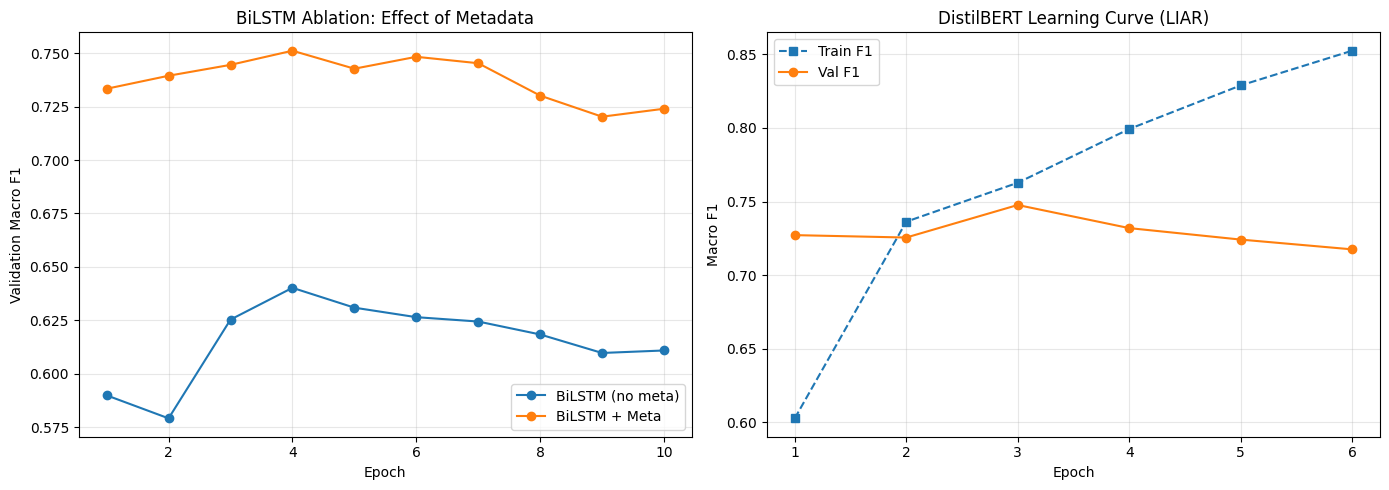

In [62]:
# ── Results Table ────────────────────────────────────────────────────────────
print('='*85)
print(f'{"Model":<40} {"Acc":>7} {"F1":>7} {"Prec":>7} {"Rec":>7} {"AUC":>7}')
print('-'*85)
for r in results:
    print(f'{r["name"]:<40} {r["acc"]:>7.4f} {r["f1"]:>7.4f} {r["prec"]:>7.4f} {r["rec"]:>7.4f} {r["auc"]:>7.4f}')
print('='*85)

# ── Learning Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BiLSTM
for label, key in [('BiLSTM (no meta)', 'BiLSTM (no metadata)'), ('BiLSTM + Meta', 'BiLSTM + Metadata')]:
    hist = bilstm_results[key]['history']
    epochs = [h['epoch'] for h in hist]
    axes[0].plot(epochs, [h['val_f1'] for h in hist], marker='o', label=label)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Macro F1')
axes[0].set_title('BiLSTM Ablation: Effect of Metadata')
axes[0].legend()
axes[0].grid(alpha=0.3)

# DistilBERT
epochs_b = [h['epoch'] for h in bert_history]
axes[1].plot(epochs_b, [h['tr_f1'] for h in bert_history], marker='s', label='Train F1', linestyle='--')
axes[1].plot(epochs_b, [h['val_f1'] for h in bert_history], marker='o', label='Val F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Macro F1')
axes[1].set_title('DistilBERT Learning Curve (LIAR)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 16 — Error Analysis

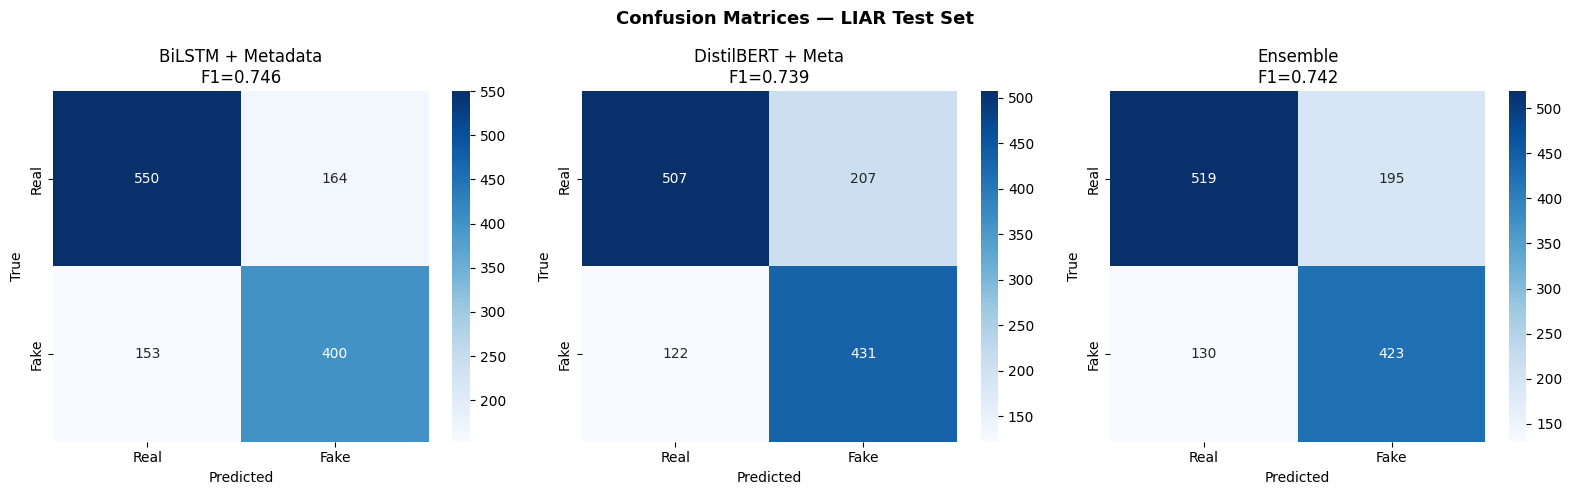


=== DistilBERT+Meta Error Examples ===

--- FALSE NEGATIVES (Fake predicted as Real) ---
  [false] speaker=facebook-posts  party=none
  stmt: "Says 57 percent of federal spending goes to the military and just 1 percent goes to food and agricul"
  fake_prob=0.384 → predicted Real

  [barely-true] speaker=robert-menendez  party=democrat
  stmt: "Says as a result of the national health care reform, the Congressional Budget Office says we save $2"
  fake_prob=0.179 → predicted Real

  [false] speaker=bill-nelson  party=democrat
  stmt: "On banning earmarks."
  fake_prob=0.444 → predicted Real

  [barely-true] speaker=democratic-national-committee  party=none
  stmt: "Mitch McConnell opposed "legislation to create and protect Kentucky jobs . . . help for the unemploy"
  fake_prob=0.292 → predicted Real

  [barely-true] speaker=rick-scott  party=republican
  stmt: "Citizens Property Insurance has over $500 billion worth of risk, with less than $10 billion worth of"
  fake_prob=0.275 → predi

In [63]:
# Confusion Matrices for the three main LIAR models
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

bert_model.load_state_dict({k: v.to(DEVICE) for k, v in best_bert_state.items()})
te_y_bert, te_p_bert, te_prob_bert = bert_evaluate(bert_model, bert_test_loader)

bilstm_best_model.load_state_dict(
    {k: v.to(DEVICE) for k, v in bilstm_results['BiLSTM + Metadata']['best_state'].items()}
)
te_y_lstm, te_p_lstm, te_prob_lstm = evaluate(bilstm_best_model, test_loader)

ens_test_pred_final = (
    (best_alpha * te_prob_bert + (1 - best_alpha) * te_prob_lstm) >= 0.5
).astype(int)

for ax, (y_true, y_pred, title) in zip(axes, [
    (te_y_lstm,           te_p_lstm,           'BiLSTM + Metadata'),
    (te_y_bert,           te_p_bert,           'DistilBERT + Meta'),
    (te_y_bert,           ens_test_pred_final, 'Ensemble'),
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title}\nF1={f1_score(y_true, y_pred, average="macro"):.3f}')

plt.suptitle('Confusion Matrices — LIAR Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Qualitative error analysis — DistilBERT+Meta
print('\n=== DistilBERT+Meta Error Examples ===')
print('\n--- FALSE NEGATIVES (Fake predicted as Real) ---')
fn_examples = [(r, p, prob) for r, p, prob in
               zip(liar_test, te_p_bert, te_prob_bert)
               if r['binary_label'] == 1 and p == 0][:5]
for r, p, prob in fn_examples:
    print(f'  [{r["label"]}] speaker={r["speaker"]}  party={r["party"]}')
    print(f'  stmt: "{r["statement"][:100]}"')
    print(f'  fake_prob={prob:.3f} → predicted Real')
    print()

print('--- FALSE POSITIVES (Real predicted as Fake) ---')
fp_examples = [(r, p, prob) for r, p, prob in
               zip(liar_test, te_p_bert, te_prob_bert)
               if r['binary_label'] == 0 and p == 1][:5]
for r, p, prob in fp_examples:
    print(f'  [{r["label"]}] speaker={r["speaker"]}  party={r["party"]}')
    print(f'  stmt: "{r["statement"][:100]}"')
    print(f'  fake_prob={prob:.3f} → predicted Fake')
    print()

## Cell 17 — Final Results Bar Chart & Classification Reports

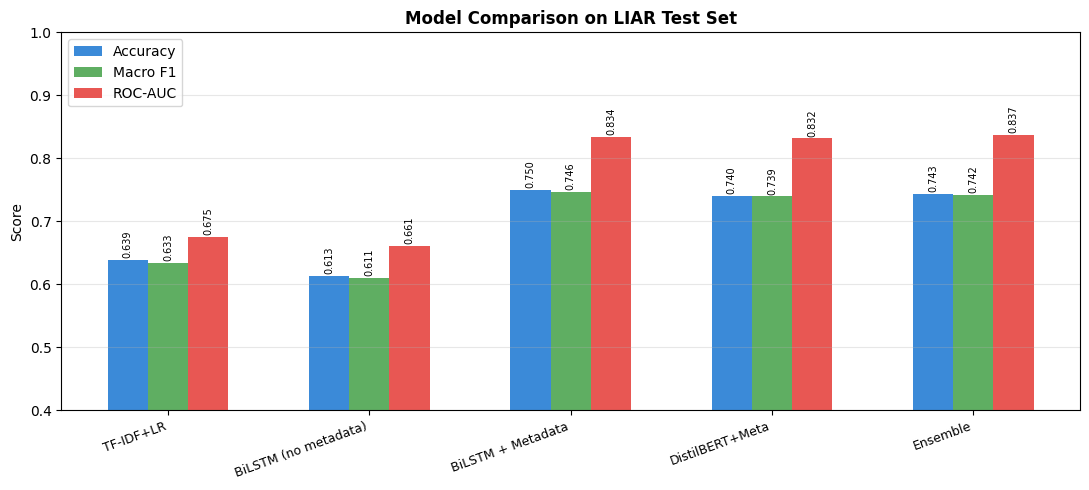


=== DistilBERT+Meta Detailed Classification Report (LIAR test) ===
              precision    recall  f1-score   support

        Real       0.81      0.71      0.76       714
        Fake       0.68      0.78      0.72       553

    accuracy                           0.74      1267
   macro avg       0.74      0.74      0.74      1267
weighted avg       0.75      0.74      0.74      1267


=== Ensemble Detailed Classification Report (LIAR test) ===
              precision    recall  f1-score   support

        Real       0.80      0.73      0.76       714
        Fake       0.68      0.76      0.72       553

    accuracy                           0.74      1267
   macro avg       0.74      0.75      0.74      1267
weighted avg       0.75      0.74      0.74      1267


=== Confidence Intervals Summary (DistilBERT+Meta, 3 runs) ===
  acc: 0.7380 ± 0.0045
  f1: 0.7367 ± 0.0045
  auc: 0.8313 ± 0.0028


In [64]:
main_models = [
    'TF-IDF+LR [LIAR test]',
    'BiLSTM (no metadata) [LIAR test]',
    'BiLSTM + Metadata [LIAR test]',
    'DistilBERT+Meta [LIAR test]',
    'Ensemble [LIAR test]'
]
main_results = [r for r in results if r['name'] in main_models]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(main_results))
width = 0.2
metrics_to_plot = [('acc', 'Accuracy'), ('f1', 'Macro F1'), ('auc', 'ROC-AUC')]
colors = ['#1976d2', '#43a047', '#e53935']

for i, (key, label) in enumerate(metrics_to_plot):
    vals = [r[key] for r in main_results]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=label, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([r['name'].replace(' [LIAR test]','') for r in main_results],
                   rotation=20, ha='right', fontsize=9)
ax.set_ylabel('Score')
ax.set_ylim(0.4, 1.0)
ax.set_title('Model Comparison on LIAR Test Set', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== DistilBERT+Meta Detailed Classification Report (LIAR test) ===')
print(classification_report(te_y_bert, te_p_bert, target_names=['Real','Fake']))

print('\n=== Ensemble Detailed Classification Report (LIAR test) ===')
print(classification_report(te_y_bert, ens_test_pred_final, target_names=['Real','Fake']))

print('\n=== Confidence Intervals Summary (DistilBERT+Meta, 3 runs) ===')
for k, v in run_metrics.items():
    print(f'  {k}: {np.mean(v):.4f} ± {np.std(v):.4f}')

Selected  fake: [1, 2, 4]  real: [6, 8, 23]


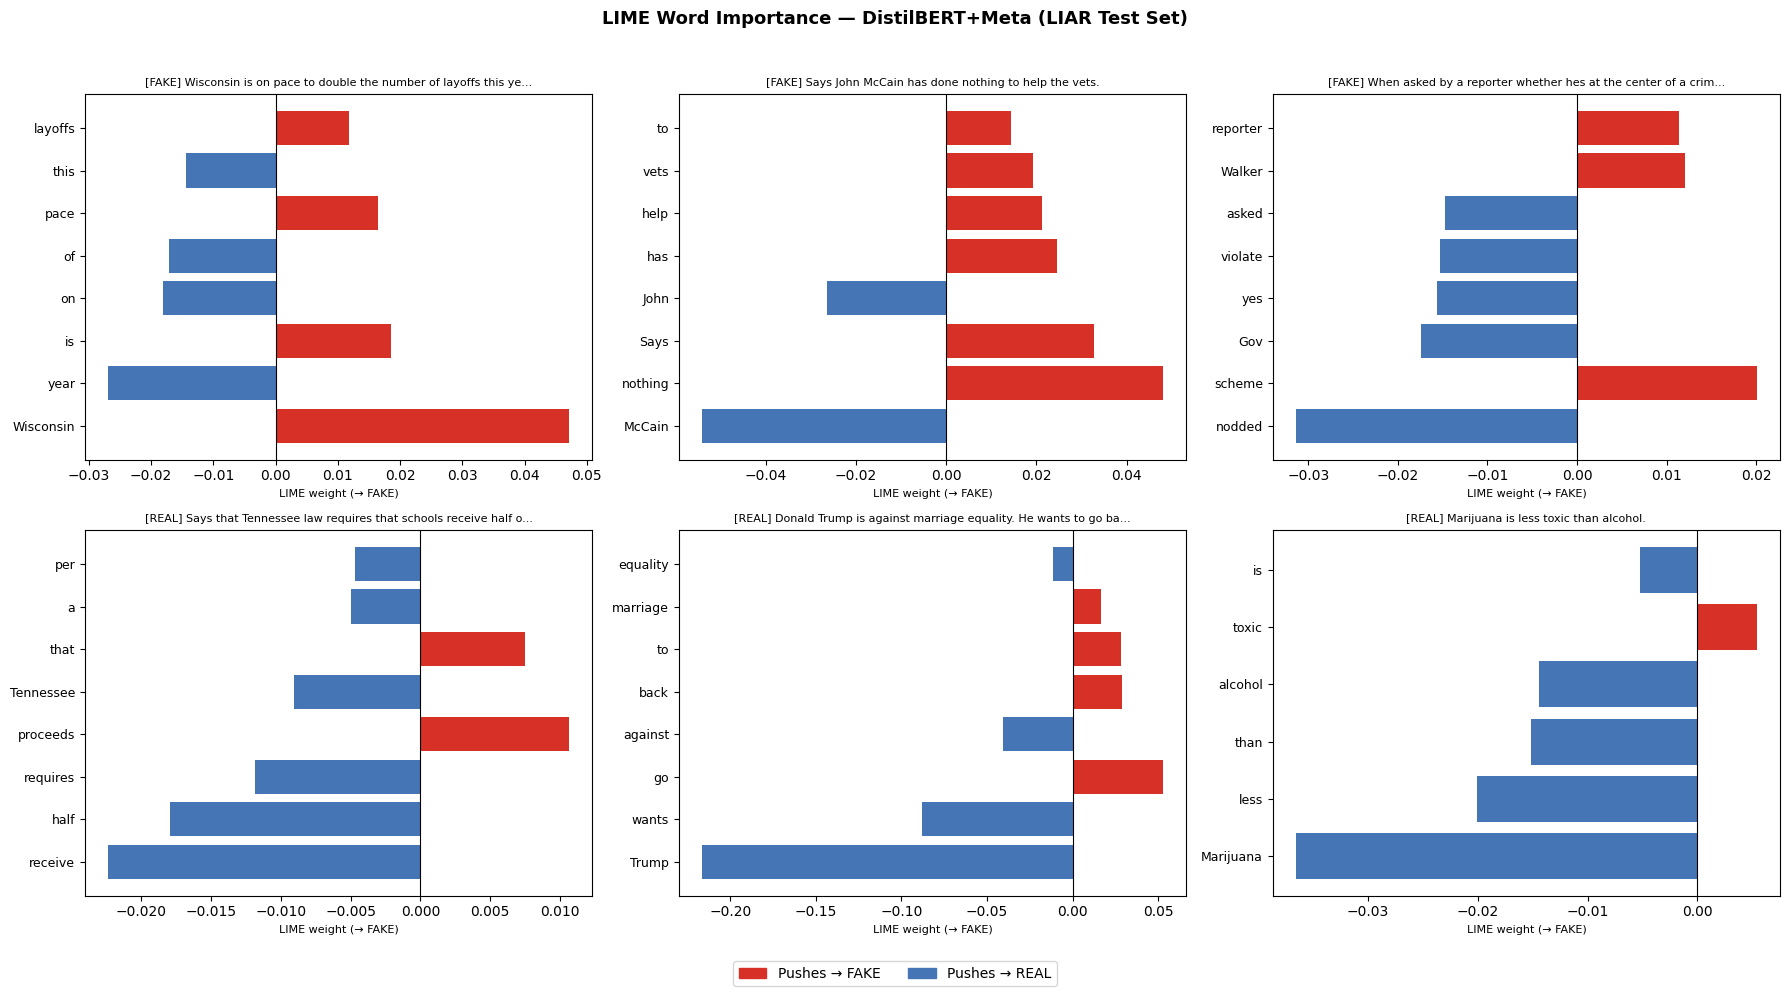

Saved: lime_explanations.png


In [68]:
# ── XAI — LIME for DistilBERT+Meta ─────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lime', '-q'], check=True)

from lime.lime_text import LimeTextExplainer
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. LIME wrapper ──────────────────────────────────────────────────────────
# LIME perturbs text while holding the sample's own metadata vector fixed.
def make_bert_predictor(model, meta_tensor, device, max_len=64):
    model.eval()
    def predict_proba(texts):
        probs = []
        for text in texts:
            enc = tokenizer(text, truncation=True, max_length=max_len,
                            padding='max_length', return_tensors='pt')
            with torch.no_grad():
                logits = model(
                    input_ids=enc['input_ids'].to(device),
                    attention_mask=enc['attention_mask'].to(device),
                    meta=meta_tensor.to(device)
                )
            p = torch.softmax(logits, dim=-1).cpu().numpy()[0]
            probs.append(p)
        return np.array(probs)
    return predict_proba

# ── 2. Pick high-confidence samples from LIAR test set ───────────────────────
lime_explainer = LimeTextExplainer(class_names=['REAL', 'FAKE'])
bert_model.eval()
sample_indices = {'fake': [], 'real': []}

with torch.no_grad():
    for i, batch in enumerate(bert_test_loader):
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        meta  = batch['meta'].to(DEVICE)
        labs  = batch['labels']
        logits = bert_model(ids, mask, meta)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = probs.argmax(axis=1)
        confs  = probs.max(axis=1)
        offset = i * bert_test_loader.batch_size
        for j in range(len(labs)):
            label = int(labs[j].item())
            pred  = int(preds[j])
            conf  = float(confs[j])
            if pred == label and conf > 0.80:
                key = 'fake' if label == 1 else 'real'
                if len(sample_indices[key]) < 3:
                    sample_indices[key].append(offset + j)
        if len(sample_indices['fake']) >= 3 and len(sample_indices['real']) >= 3:
            break

selected = sample_indices['fake'] + sample_indices['real']
print(f'Selected  fake: {sample_indices["fake"]}  real: {sample_indices["real"]}')

# ── 3. Generate LIME explanations ────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax_idx, sample_i in enumerate(selected):
    record = liar_test[sample_i]
    text   = record['statement']
    label  = record['binary_label']
    meta_t = torch.tensor([build_meta_vector(record)], dtype=torch.float32)  # (1, 12)

    predictor = make_bert_predictor(bert_model, meta_t, DEVICE)
    exp = lime_explainer.explain_instance(
        text, predictor, num_features=8, num_samples=200, labels=[1]
    )

    exp_list = exp.as_list(label=1)
    if exp_list:
        words, weights = zip(*exp_list)
    else:
        words, weights = ['—'], [0.0]
    colors = ['#d73027' if w > 0 else '#4575b4' for w in weights]

    ax = axes[ax_idx]
    ax.barh(range(len(words)), weights, color=colors)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    true_lbl   = 'FAKE' if label == 1 else 'REAL'
    short_text = text[:60] + '...' if len(text) > 60 else text
    ax.set_title(f'[{true_lbl}] {short_text}', fontsize=8, wrap=True)
    ax.set_xlabel('LIME weight (→ FAKE)', fontsize=8)

red_patch  = mpatches.Patch(color='#d73027', label='Pushes → FAKE')
blue_patch = mpatches.Patch(color='#4575b4', label='Pushes → REAL')
fig.legend(handles=[red_patch, blue_patch], loc='lower center', ncol=2, fontsize=10)
fig.suptitle('LIME Word Importance — DistilBERT+Meta (LIAR Test Set)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('lime_explanations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lime_explanations.png')


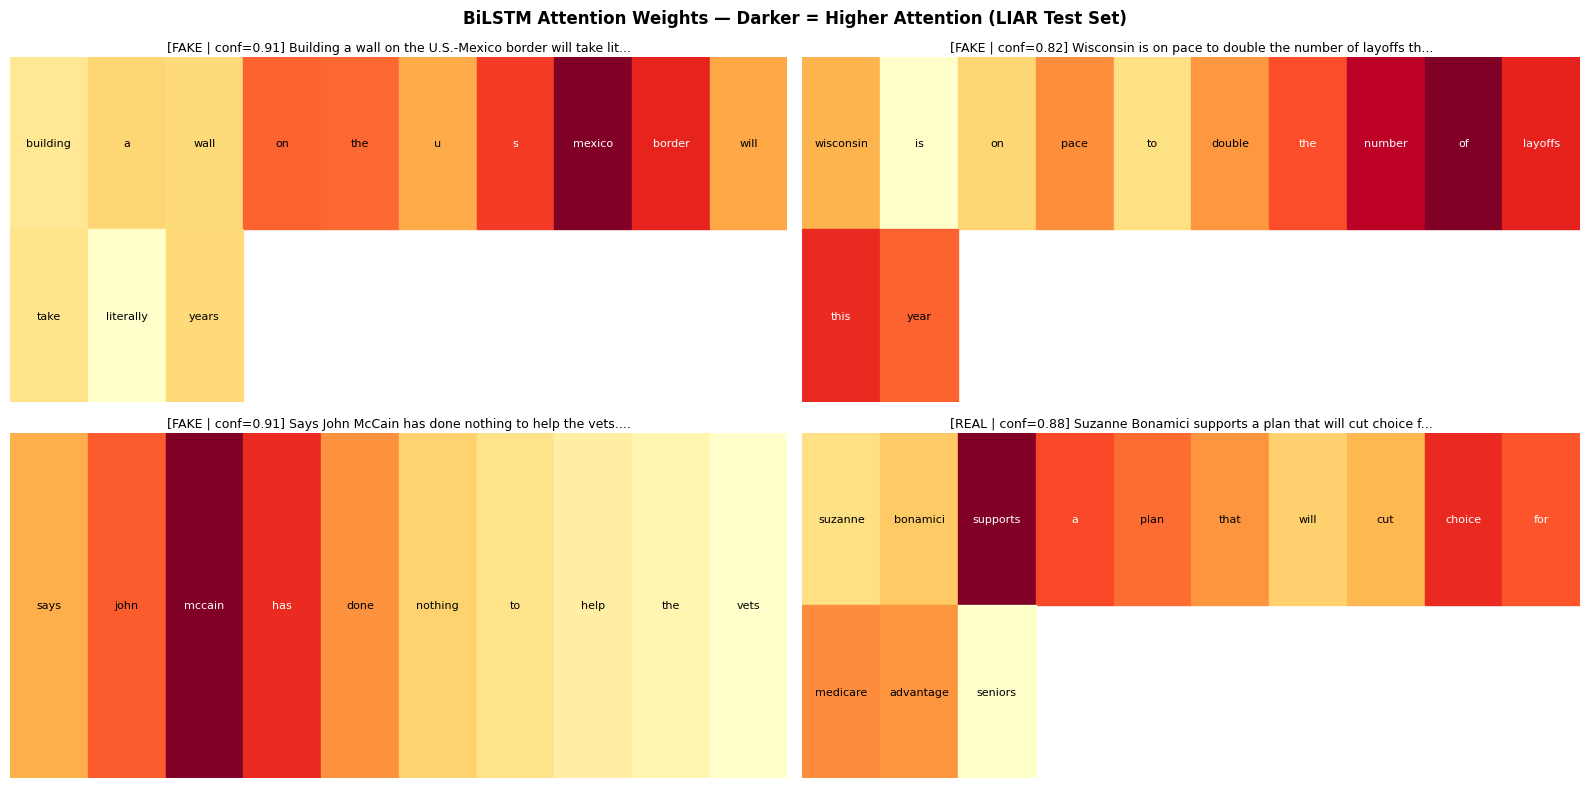

Saved: bilstm_attention.png


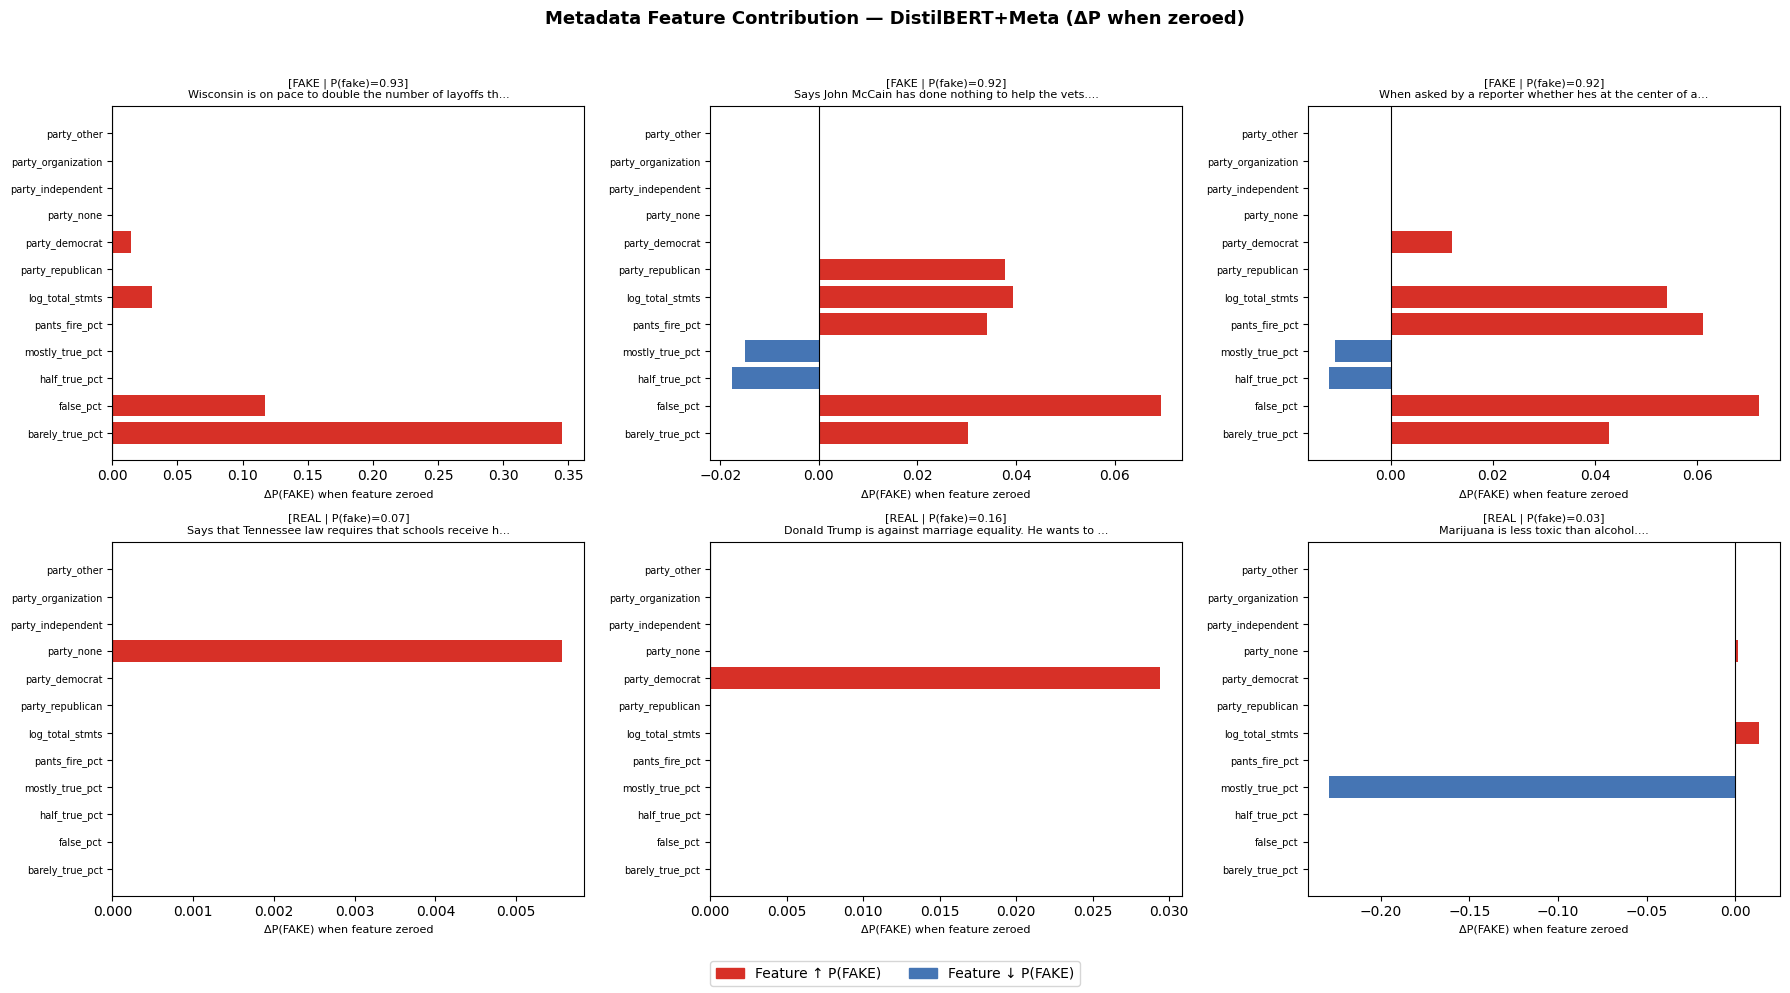

Saved: metadata_contributions.png


In [70]:
# ── XAI — BiLSTM Attention Visualization & Metadata Contribution ────────────
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

bilstm_meta_model = bilstm_results['BiLSTM + Metadata']['model'].to(DEVICE)
bilstm_meta_model.eval()

# ── A. Extract BiLSTM attention weights ──────────────────────────────────────
def bilstm_attention(model, record, device):
    """Returns (tokens, attention_weights) for one LIAR record."""
    model.eval()
    tokens = record['clean_statement'].split()
    ids    = encode_tokens(record['clean_statement'])          # padded to MAX_SEQ_LEN
    meta_v = record['credit_features'] + [np.log1p(record['credit_total'])]
    x    = torch.tensor([ids],    dtype=torch.long).to(device)
    meta = torch.tensor([meta_v], dtype=torch.float32).to(device)
    with torch.no_grad():
        emb    = model.embedding(x)                            # (1, T, E)
        out, _ = model.lstm(emb)                               # (1, T, 2H)
        attn_w = torch.softmax(model.attn(out), dim=1)        # (1, T, 1)
        weights = attn_w.squeeze().cpu().numpy()               # (T,)
    n = min(len(tokens), MAX_SEQ_LEN)
    if weights.ndim == 0:
        weights = np.array([float(weights)])
    return tokens[:n], weights[:n]


def plot_attention_heatmap(tokens, weights, title, ax):
    weights_norm = (weights - weights.min()) / (weights.max() - weights.min() + 1e-9)
    cols = min(len(tokens), 10)
    rows = (len(tokens) + cols - 1) // cols
    cell_w, cell_h = 1.0, 0.5
    ax.set_xlim(0, cols * cell_w)
    ax.set_ylim(0, rows * cell_h)
    ax.axis('off')
    ax.set_title(title, fontsize=9, pad=4)
    for idx, (tok, w) in enumerate(zip(tokens, weights_norm)):
        row = idx // cols
        col = idx %  cols
        rect = plt.Rectangle((col * cell_w, (rows - 1 - row) * cell_h),
                              cell_w, cell_h, color=plt.cm.YlOrRd(w))
        ax.add_patch(rect)
        text_color = 'white' if w > 0.6 else 'black'
        ax.text(col * cell_w + cell_w/2, (rows - 1 - row) * cell_h + cell_h/2,
                tok, ha='center', va='center', fontsize=8, color=text_color)


# Pick 4 high-confidence correct predictions for attention visualization
attn_samples = []
with torch.no_grad():
    for ids_b, meta_b, labs_b in test_loader:
        ids_b  = ids_b.to(DEVICE)
        meta_b = meta_b.to(DEVICE)
        logits = bilstm_meta_model(ids_b, meta_b)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()
        preds  = probs.argmax(axis=1)
        for j in range(len(labs_b)):
            label = int(labs_b[j].item())
            pred  = int(preds[j])
            conf  = float(probs[j][pred])
            if pred == label and conf > 0.78 and len(attn_samples) < 4:
                # Approximate global index: test_loader is not shuffled
                global_i = len(attn_samples)
                attn_samples.append({'label': label, 'conf': conf,
                                     'record': liar_test[global_i]})
        if len(attn_samples) >= 4:
            break

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
for ax_idx, s in enumerate(attn_samples):
    tokens, weights = bilstm_attention(bilstm_meta_model, s['record'], DEVICE)
    lbl   = 'FAKE' if s['label'] == 1 else 'REAL'
    title = f'[{lbl} | conf={s["conf"]:.2f}] {s["record"]["statement"][:55]}...'
    plot_attention_heatmap(tokens, weights, title, axes[ax_idx])

fig.suptitle('BiLSTM Attention Weights — Darker = Higher Attention (LIAR Test Set)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('bilstm_attention.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: bilstm_attention.png')


# ── B. Metadata Contribution Breakdown ───────────────────────────────────────
META_LABELS = [
    'barely_true_pct', 'false_pct', 'half_true_pct',
    'mostly_true_pct', 'pants_fire_pct', 'log_total_stmts',
    'party_republican', 'party_democrat', 'party_none',
    'party_independent', 'party_organization', 'party_other'
]

def meta_contribution(model, record, device, max_len=64):
    """ΔP(FAKE) when each metadata feature is zeroed — measures feature importance."""
    meta_arr = np.array(build_meta_vector(record), dtype=np.float32)
    text     = record['clean_statement']
    enc = tokenizer(text, truncation=True, max_length=max_len,
                    padding='max_length', return_tensors='pt')
    model.eval()
    with torch.no_grad():
        base_p = torch.softmax(
            model(enc['input_ids'].to(device), enc['attention_mask'].to(device),
                  torch.tensor([meta_arr]).to(device)), dim=-1
        ).cpu().numpy()[0][1]

    contribs = []
    for fi in range(len(meta_arr)):
        ablated = meta_arr.copy()
        ablated[fi] = 0.0
        with torch.no_grad():
            abl_p = torch.softmax(
                model(enc['input_ids'].to(device), enc['attention_mask'].to(device),
                      torch.tensor([ablated]).to(device)), dim=-1
            ).cpu().numpy()[0][1]
        contribs.append(float(base_p - abl_p))
    return float(base_p), np.array(contribs)


# Run on the same 6 samples used for LIME
meta_examples = sample_indices['fake'][:3] + sample_indices['real'][:3]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax_idx, si in enumerate(meta_examples):
    record   = liar_test[si]
    label    = record['binary_label']
    base_p, contribs = meta_contribution(bert_model, record, DEVICE)

    ax = axes[ax_idx]
    colors = ['#d73027' if c > 0 else '#4575b4' for c in contribs]
    ax.barh(META_LABELS, contribs, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    lbl_str = 'FAKE' if label == 1 else 'REAL'
    ax.set_title(f'[{lbl_str} | P(fake)={base_p:.2f}]\n{record["statement"][:55]}...',
                 fontsize=8)
    ax.set_xlabel('ΔP(FAKE) when feature zeroed', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

red_patch  = mpatches.Patch(color='#d73027', label='Feature ↑ P(FAKE)')
blue_patch = mpatches.Patch(color='#4575b4', label='Feature ↓ P(FAKE)')
fig.legend(handles=[red_patch, blue_patch], loc='lower center', ncol=2, fontsize=10)
fig.suptitle('Metadata Feature Contribution — DistilBERT+Meta (ΔP when zeroed)',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.96])
plt.savefig('metadata_contributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: metadata_contributions.png')


## Cell 18 — Summary & Saved Artifacts
All figures and the final results dictionary are saved for inclusion in the report.

In [71]:
import json

with open('results_summary.json', 'w') as f:
    json.dump({
        'all_results': results,
        'distilbert_runs': run_metrics,
        'ensemble_alpha': best_alpha
    }, f, indent=2)

from google.colab import files
for fname in ['eda_overview.png', 'learning_curves.png',
              'confusion_matrices.png', 'model_comparison.png',
              'lime_explanations.png', 'bilstm_attention.png',
              'metadata_contributions.png', 'results_summary.json']:
    if os.path.exists(fname):
        files.download(fname)

print('Done. Artifacts downloaded.')
print()
print('=== FINAL RESULTS SUMMARY ===')
print(f'{"Model":<45} {"F1":>7} {"Acc":>7} {"AUC":>7}')
print('-'*65)
keep = [
    'TF-IDF+LR [LIAR test]',
    'BiLSTM (no metadata) [LIAR test]',
    'BiLSTM + Metadata [LIAR test]',
    'DistilBERT+Meta [LIAR test]',
    'Ensemble [LIAR test]',
    'Stacked Ensemble [LIAR test]',
    'DistilBERT [BuzzFeed test]',
    'TF-IDF+LR [BuzzFeed test]',
    'DistilBERT+Meta LIAR->BuzzFeed (mean-meta OOD)',
    'TF-IDF+LR LIAR->BuzzFeed (OOD)',
]
for name in keep:
    r = next((x for x in results if x['name'] == name), None)
    if r:
        print(f'{r["name"]:<45} {r["f1"]:>7.4f} {r["acc"]:>7.4f} {r["auc"]:>7.4f}')

print()
print(f'DistilBERT+Meta 3-run: F1={np.mean(run_metrics["f1"]):.4f} +/- {np.std(run_metrics["f1"]):.4f}  '
      f'AUC={np.mean(run_metrics["auc"]):.4f} +/- {np.std(run_metrics["auc"]):.4f}')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done. Artifacts downloaded.

=== FINAL RESULTS SUMMARY ===
Model                                              F1     Acc     AUC
-----------------------------------------------------------------
TF-IDF+LR [LIAR test]                          0.6333  0.6385  0.6754
BiLSTM (no metadata) [LIAR test]               0.6107  0.6133  0.6608
BiLSTM + Metadata [LIAR test]                  0.7462  0.7498  0.8339
DistilBERT+Meta [LIAR test]                    0.7394  0.7403  0.8316
Ensemble [LIAR test]                           0.7420  0.7435  0.8366
Stacked Ensemble [LIAR test]                   0.7448  0.7490  0.8392
DistilBERT [BuzzFeed test]                     0.6748  0.6786  0.6990
TF-IDF+LR [BuzzFeed test]                      0.6782  0.6786  0.7092

DistilBERT+Meta 3-run: F1=0.7367 +/- 0.0045  AUC=0.8313 +/- 0.0028
